## Imports

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
from pathlib import Path
import json
import time
from datetime import datetime
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    precision_recall_fscore_support,
    accuracy_score
)

try:
    from mamba_ssm import Mamba
except ImportError:
    print("Warning: mamba_ssm not installed. Install with: pip install mamba-ssm")
    Mamba = None

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Device: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.4.0+cu121
CUDA Available: True
CUDA Device: NVIDIA GeForce RTX 4060


## Adjecancy Matrix Generation

In [27]:
POSE_EDGES = [
    (11, 13), (13, 15),     # left arm
    (12, 14), (14, 16),     # right arm
    (11, 12),               # shoulders
    (11, 23), (12, 24),     # torso
    (23, 24),               # hips
]

LEFT_HAND_BASE = 33

LEFT_HAND_EDGES = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (0, 5), (5, 6), (6, 7), (7, 8),
    (0, 9), (9,10), (10,11), (11,12),
    (0,13), (13,14), (14,15), (15,16),
    (0,17), (17,18), (18,19), (19,20),
]

LEFT_HAND_EDGES = [
    (a + LEFT_HAND_BASE, b + LEFT_HAND_BASE)
    for a, b in LEFT_HAND_EDGES
]

RIGHT_HAND_BASE = 54

RIGHT_HAND_EDGES = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (0, 5), (5, 6), (6, 7), (7, 8),
    (0, 9), (9,10), (10,11), (11,12),
    (0,13), (13,14), (14,15), (15,16),
    (0,17), (17,18), (18,19), (19,20),
]

RIGHT_HAND_EDGES = [
    (a + RIGHT_HAND_BASE, b + RIGHT_HAND_BASE)
    for a, b in RIGHT_HAND_EDGES
]

EDGES = POSE_EDGES + LEFT_HAND_EDGES + RIGHT_HAND_EDGES
NUM_JOINTS = 75

In [28]:
def build_adjacency(num_nodes, edges):
    A = np.zeros((num_nodes, num_nodes), dtype=np.float32)
    for i, j in edges:
        A[i, j] = 1
        A[j, i] = 1
    return A

In [29]:
def add_self_loops(A):
    return A + np.eye(A.shape[0], dtype=A.dtype)

In [30]:
def add_self_loops(A):
    return A + np.eye(A.shape[0], dtype=A.dtype)

In [31]:
def normalize_adjacency(A):
    D = np.sum(A, axis=1)
    D_inv = np.diag(1.0 / (D + 1e-6))
    return D_inv @ A

In [32]:
def spatial_partition(A, center):
    num_nodes = A.shape[0]

    hop_dis = np.full((num_nodes, num_nodes), np.inf)
    for i in range(num_nodes):
        hop_dis[i, i] = 0

    for i in range(num_nodes):
        for j in range(num_nodes):
            if A[i, j] > 0:
                hop_dis[i, j] = 1

    A_self = np.eye(num_nodes)
    A_in = np.zeros_like(A)
    A_out = np.zeros_like(A)

    for i in range(num_nodes):
        for j in range(num_nodes):
            if hop_dis[j, center] == hop_dis[i, center] + 1:
                A_in[j, i] = A[j, i]
            elif hop_dis[j, center] == hop_dis[i, center] - 1:
                A_out[j, i] = A[j, i]

    return A_self, A_in, A_out


## Configurations

In [33]:
class Config:
    """Centralized configuration for training"""
    
    # Paths
    TRAIN_SEQ = "processed/seq/seq_train"
    TRAIN_MASK = "processed/mask/mask_train"
    VAL_SEQ = "processed/seq/seq_val"
    VAL_MASK = "processed/mask/mask_val"
    TEST_SEQ = "processed/seq/seq_test"
    TEST_MASK = "processed/mask/mask_test"
    AUGMENT_TEST_SEQ = "processed/seq/seq_augment_test"
    AUGMENT_TEST_MASK = "processed/mask/mask_augment_test"

    
    # Model parameters
    IN_CHANNELS = 3
    NUM_JOINTS = 75
    
    # Training parameters
    BATCH_SIZE = 16
    NUM_EPOCHS = 50
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-4
    
    # Scheduler
    STEP_SIZE = 20
    GAMMA = 0.1
    
    # Optimizer
    GRAD_CLIP = 1.0
    
    # Saving
    CHECKPOINT_DIR = "checkpoints_mamba_og"
    RESULTS_DIR = "results_mamba_og"
    
    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    NUM_WORKERS = 0  # should be 4 but Kaggle dont support multiprocessing i guess

# Create directories
Path(Config.CHECKPOINT_DIR).mkdir(exist_ok=True)
Path(Config.RESULTS_DIR).mkdir(exist_ok=True)

print(f"Training Device: {Config.DEVICE}")
print(f"Batch Size: {Config.BATCH_SIZE}")
print(f"Learning Rate: {Config.LEARNING_RATE}")

Training Device: cuda
Batch Size: 16
Learning Rate: 0.001


## Helper Functions

In [34]:
def downsample_mask(mask, stride):
    """
    Downsample temporal mask by taking max over stride windows.
    
    Args:
        mask: (N, T) tensor of 0s and 1s
        stride: downsampling factor
    
    Returns:
        mask_down: (N, T_down) downsampled mask
    """
    if stride == 1:
        return mask
    
    mask = mask.unsqueeze(1)  # (N, 1, T)
    mask = F.max_pool1d(mask, kernel_size=stride, stride=stride, ceil_mode=False)
    return mask.squeeze(1)  # (N, T_down)


def format_time(seconds):
    """Convert seconds to readable time format"""
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    return f"{hours:02d}:{minutes:02d}:{secs:02d}"

In [35]:
# Load adjacency matrix 
CENTER_JOINT = 11  # left shoulder 
A = build_adjacency(NUM_JOINTS, EDGES)
A = add_self_loops(A)
A = normalize_adjacency(A)

A_self, A_in, A_out = spatial_partition(A, CENTER_JOINT)

A_stgcn = np.stack([A_self, A_in, A_out], axis=0)


## Model Architecture

In [36]:
class BiTemporalMambaGCNBlock(nn.Module):
    """
    Strict Bidirectional Temporal Mamba-GCN Block.
    Maintains 1:1 architecture with ST-GCN but uses a dual-scan 
    Mamba for superior temporal robustness.
    """
    def __init__(self, in_channels, out_channels, A, stride=1, residual=True, dropout=0.5):
        super().__init__()
        self.register_buffer("A", torch.tensor(A, dtype=torch.float32))
        self.K = A.shape[0]
        self.stride = stride
        self.out_channels = out_channels
        
        # 1. Spatial GCN (Identical to ST-GCN)
        self.gcn = nn.Conv2d(in_channels, out_channels * self.K, kernel_size=1)
        
        # 2. Bidirectional Temporal Mamba
        self.norm = nn.LayerNorm(out_channels)
        
        # Forward Scan
        self.mamba_fwd = Mamba(d_model=out_channels, d_state=16, d_conv=4, expand=2)
        # Backward Scan
        self.mamba_bwd = Mamba(d_model=out_channels, d_state=16, d_conv=4, expand=2)
        
        # Projection to merge Bi-Mamba back to out_channels
        self.proj = nn.Linear(out_channels * 2, out_channels)
        self.dropout = nn.Dropout(p=dropout)
        
        # 3. Learnable Pooling for Strides
        if stride > 1:
            self.temporal_pool = nn.Conv1d(out_channels, out_channels, kernel_size=5, 
                                          stride=stride, padding=2, groups=out_channels)
        else:
            self.temporal_pool = None
            
        # 4. Residual
        if not residual:
            self.residual = lambda x: 0
        elif in_channels == out_channels and stride == 1:
            self.residual = nn.Identity()
        else:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=(stride, 1)),
                nn.BatchNorm2d(out_channels)
            )
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x, mask):
        N, C_in, T, V = x.shape
        
        # Spatial Pass
        x_gcn = self.gcn(x)
        x_gcn = x_gcn.view(N, self.K, self.out_channels, T, V)
        x_gcn = torch.einsum('nkctv,kvw->nctw', x_gcn, self.A)
        
        # Temporal Pass (Reshape to N*V, T, C)
        x_temp = x_gcn.permute(0, 3, 2, 1).contiguous()
        x_temp = x_temp.view(N * V, T, self.out_channels)
        x_temp = self.norm(x_temp)
        
        # Forward Scan
        feat_fwd = self.mamba_fwd(x_temp)
        
        # Backward Scan (Flip sequence -> Scan -> Flip back)
        feat_bwd = self.mamba_bwd(x_temp.flip(dims=[1])).flip(dims=[1])
        
        # Combine and Project
        x_mamba = torch.cat([feat_fwd, feat_bwd], dim=-1)
        x_mamba = self.proj(x_mamba)
        x_mamba = self.dropout(x_mamba)
        
        # Downsampling & Reshaping
        x_mamba = x_mamba.transpose(1, 2)
        if self.temporal_pool is not None:
            x_mamba = self.temporal_pool(x_mamba)
            T_new = x_mamba.shape[2]
        else:
            T_new = T 
        
        x_mamba = x_mamba.view(N, V, self.out_channels, T_new)
        x_mamba = x_mamba.permute(0, 2, 3, 1).contiguous()

        res = self.residual(x)
        x_out = x_mamba + res
        
        # Residual & Output
        if self.stride > 1:
            mask = mask.unsqueeze(1)
            mask = F.max_pool1d(mask, kernel_size=self.stride, stride=self.stride)
            mask = mask.squeeze(1)
        
        x_out = x_out * mask[:, None, :, None]
        
        return self.relu(x_out), mask

In [37]:
class MambaGCN(nn.Module):
    """
    Mamba-GCN: Spatial-Temporal Graph Convolutional Network with Mamba
    for Skeleton-based Action Recognition
    """
    
    def __init__(self, num_classes, A, in_channels=3, dropout=0.3):
        super().__init__()
        
        # Input Batch Normalization
        self.data_bn = nn.BatchNorm1d(in_channels * A.shape[1])
        
        # Mamba-GCN Blocks
        self.layer1 = BiTemporalMambaGCNBlock(in_channels, 64, A, stride=1, residual=False, dropout=dropout)
        self.layer2 = BiTemporalMambaGCNBlock(64, 64, A, stride=1, dropout=dropout)
        self.layer3 = BiTemporalMambaGCNBlock(64, 64, A, stride=1, dropout=dropout)
        self.layer4 = BiTemporalMambaGCNBlock(64, 128, A, stride=2, dropout=dropout)
        self.layer5 = BiTemporalMambaGCNBlock(128, 256, A, stride=2, dropout=dropout)
        
        # Classifier
        self.fc = nn.Linear(256, num_classes)
    
    def forward(self, x, mask):
        """
        Args:
            x: (N, C, T, V) - input skeleton sequences
            mask: (N, T) - temporal mask
        
        Returns:
            logits: (N, num_classes) - classification logits
        """
        N, C, T, V = x.shape
        
        # Input normalization
        x = x.permute(0, 3, 1, 2).contiguous()  # (N, V, C, T)
        x = x.view(N, V * C, T)
        x = self.data_bn(x)
        x = x.view(N, V, C, T).permute(0, 2, 3, 1)  # (N, C, T, V)
        
        # Mamba-GCN layers
        x, mask = self.layer1(x, mask)
        x, mask = self.layer2(x, mask)
        x, mask = self.layer3(x, mask)
        x, mask = self.layer4(x, mask)
        x, mask = self.layer5(x, mask)
        
        # Masked Global Average Pooling
        x = x * mask[:, None, :, None]  # Apply mask
        x_sum = x.sum(dim=[2, 3])  # (N, C)
        valid_count = mask.sum(dim=1, keepdim=True) * V  # (N, 1)
        x = x_sum / (valid_count + 1e-6)  # Avoid division by zero
        
        # Classification
        logits = self.fc(x)
        return logits



## Dataset

In [38]:
class SkeletonDataset(Dataset):
    def __init__(self, seq_dir, mask_dir, class_to_idx):
        self.samples = []
        self.class_to_idx = class_to_idx
        
        seq_dir = Path(seq_dir)
        mask_dir = Path(mask_dir)
        
        for class_name in sorted(seq_dir.iterdir()):
            if not class_name.is_dir():
                continue
            
            label = self.class_to_idx[class_name.name]
            
            for file in class_name.glob("*.npy"):
                mask_name = file.name.replace('_seq.npy', '_mask.npy')
                mask_file = mask_dir / class_name.name / mask_name
                
                if mask_file.exists():
                    self.samples.append((file, mask_file, label))
        
        print(f"Loaded {len(self.samples)} samples")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        seq_path, mask_path, label = self.samples[idx]
        
        seq = np.load(seq_path)  # (T, V, C)
        mask = np.load(mask_path)  # (T,)
        
        seq = torch.tensor(seq, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)
        
        seq = seq.permute(2, 0, 1)  # (C, T, V)
        
        return seq, mask, label

# Build class mapping
classes = sorted([p.name for p in Path(Config.TRAIN_SEQ).iterdir() if p.is_dir()])
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

print(f"Number of classes: {len(classes)}")

# Create datasets
train_dataset = SkeletonDataset(Config.TRAIN_SEQ, Config.TRAIN_MASK, class_to_idx)
val_dataset = SkeletonDataset(Config.VAL_SEQ, Config.VAL_MASK, class_to_idx)
test_dataset = SkeletonDataset(Config.TEST_SEQ, Config.TEST_MASK, class_to_idx)
test_augment_dataset = SkeletonDataset(Config.AUGMENT_TEST_SEQ, Config.AUGMENT_TEST_MASK, class_to_idx)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=Config.NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS, pin_memory=True)
test_augment_loader = DataLoader(test_augment_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Test augment batches: {len(test_augment_loader)}")

Number of classes: 121
Loaded 4235 samples
Loaded 847 samples
Loaded 968 samples
Loaded 1935 samples
Train batches: 265
Val batches: 53
Test batches: 61
Test augment batches: 121


## Metrics and Utilities

In [39]:
class MetricsTracker:
    def __init__(self):
        self.reset()
    
    def reset(self):
        self.predictions = []
        self.targets = []
        self.losses = []
    
    def update(self, outputs, targets, loss):
        preds = torch.argmax(outputs, dim=1)
        self.predictions.extend(preds.cpu().numpy())
        self.targets.extend(targets.cpu().numpy())
        self.losses.append(loss)
    
    def compute(self):
        avg_loss = np.mean(self.losses)
        accuracy = accuracy_score(self.targets, self.predictions)
        return {
            'loss': avg_loss,
            'accuracy': accuracy,
            'predictions': np.array(self.predictions),
            'targets': np.array(self.targets)
        }

def compute_detailed_metrics(y_true, y_pred, class_names):
    """
    Compute precision, recall, F1-score for each class and overall
    
    Returns:
        dict with per-class and macro/weighted averages
    """
    # Per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )
    
    # Macro averages
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    
    # Weighted averages
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    
    # Build results dictionary
    results = {
        'per_class': {
            class_names[i]: {
                'precision': float(precision[i]),
                'recall': float(recall[i]),
                'f1_score': float(f1[i]),
                'support': int(support[i])
            }
            for i in range(len(class_names))
        },
        'macro_avg': {
            'precision': float(macro_precision),
            'recall': float(macro_recall),
            'f1_score': float(macro_f1)
        },
        'weighted_avg': {
            'precision': float(weighted_precision),
            'recall': float(weighted_recall),
            'f1_score': float(weighted_f1)
        },
        'accuracy': float(accuracy_score(y_true, y_pred))
    }
    
    return results

def plot_training_history(history, save_path=None):
    """Plot training and validation metrics"""
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss plot
    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=4)
    axes[0].plot(epochs, history['val_loss'], 'r-s', label='Val Loss', linewidth=2, markersize=4)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train Accuracy', linewidth=2, markersize=4)
    axes[1].plot(epochs, history['val_acc'], 'r-s', label='Val Accuracy', linewidth=2, markersize=4)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0, 1])
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Training history saved to {save_path}")
    
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names, save_path=None, normalize=False):
    """
    Plot confusion matrix with optional normalization
    
    Args:
        normalize: If True, normalize by true class (shows recall)
    """
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-10)
        title = 'Normalized Confusion Matrix'
        fmt = '.2f'
    else:
        title = 'Confusion Matrix'
        fmt = 'd'
    
    plt.figure(figsize=(max(12, len(class_names) * 0.3), max(10, len(class_names) * 0.3)))
    
    sns.heatmap(
        cm,
        annot=False,  # Too many classes for annotations
        fmt=fmt,
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={'label': 'Proportion' if normalize else 'Count'}
    )
    
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=90, fontsize=6)
    plt.yticks(rotation=0, fontsize=6)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Confusion matrix saved to {save_path}")
    
    plt.show()
    
    return cm


def print_metrics_summary(metrics, split_name="Validation"):
    """Print formatted metrics summary"""
    
    print(f"\n{'='*60}") 
    print(f"{split_name} Metrics Summary")
    print(f"{'='*60}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"\nMacro Averages:")
    print(f"  Precision: {metrics['macro_avg']['precision']:.4f}")
    print(f"  Recall:    {metrics['macro_avg']['recall']:.4f}")
    print(f"  F1-Score:  {metrics['macro_avg']['f1_score']:.4f}")
    print(f"\nWeighted Averages:")
    print(f"  Precision: {metrics['weighted_avg']['precision']:.4f}")
    print(f"  Recall:    {metrics['weighted_avg']['recall']:.4f}")
    print(f"  F1-Score:  {metrics['weighted_avg']['f1_score']:.4f}")
    print(f"{'='*60}\n")

def format_time(seconds):
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    return f"{hours:02d}:{minutes:02d}:{secs:02d}"

def train_one_epoch(model, loader, criterion, optimizer, device, scaler):
    model.train()
    tracker = MetricsTracker()
    
    pbar = tqdm(loader, desc="Training", leave=False)
    
    for seq, mask, labels in pbar:
        seq = seq.to(device)
        mask = mask.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        with torch.amp.autocast('cuda', dtype=torch.float16):
            outputs = model(seq, mask)
            loss = criterion(outputs, labels)
        
        # Scale loss and backprop
        scaler.scale(loss).backward()
        
        # Unscale before clipping gradients to prevent clipping skewed values
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=Config.GRAD_CLIP)
        
        # Step and update scaler
        scaler.step(optimizer)
        scaler.update()
        
        tracker.update(outputs.detach(), labels, loss.item())
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
    
    return tracker.compute()
    

@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    tracker = MetricsTracker()
    
    pbar = tqdm(loader, desc="Validation", leave=False)
    for seq, mask, labels in pbar:
        seq = seq.to(device)
        mask = mask.to(device)
        labels = labels.to(device)
        
        outputs = model(seq, mask)
        loss = criterion(outputs, labels)
        
        tracker.update(outputs, labels, loss.item())
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
    
    return tracker.compute()

## Initialization

In [40]:
# Initialize model
model = MambaGCN(
    num_classes=len(classes),
    A=A_stgcn,
    in_channels=Config.IN_CHANNELS,
    dropout=0.3
).to(Config.DEVICE)

# Loss and optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE, weight_decay=Config.WEIGHT_DECAY)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=Config.STEP_SIZE, gamma=Config.GAMMA)
scaler = torch.amp.GradScaler('cuda')

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Total parameters: 1,720,187
Trainable parameters: 1,720,187


## Main Training Loop

In [41]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_val_acc = 0.0
best_epoch = 0
best_model_path = Path(Config.CHECKPOINT_DIR) / "best_mamba_gcn.pth"

print(f"\n{'='*60}")
print(f"Starting Mamba-GCN Training - {Config.NUM_EPOCHS} Epochs")
print(f"{'='*60}\n")

start_time = time.time()

for epoch in range(Config.NUM_EPOCHS):
    epoch_start = time.time()
    
    train_results = train_one_epoch(model, train_loader, criterion, optimizer, Config.DEVICE, scaler)
    val_results = validate(model, val_loader, criterion, Config.DEVICE)
    
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    
    history['train_loss'].append(train_results['loss'])
    history['train_acc'].append(train_results['accuracy'])
    history['val_loss'].append(val_results['loss'])
    history['val_acc'].append(val_results['accuracy'])
    history['lr'].append(current_lr)
    
    epoch_time = time.time() - epoch_start
    elapsed_time = time.time() - start_time
    
    print(f"Epoch [{epoch+1:3d}/{Config.NUM_EPOCHS}] "
          f"| Train Loss: {train_results['loss']:.4f} "
          f"| Train Acc: {train_results['accuracy']:.4f} "
          f"| Val Loss: {val_results['loss']:.4f} "
          f"| Val Acc: {val_results['accuracy']:.4f} "
          f"| LR: {current_lr:.6f} "
          f"| Time: {format_time(epoch_time)}")
    
    if val_results['accuracy'] > best_val_acc:
        best_val_acc = val_results['accuracy']
        best_epoch = epoch + 1
        
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_acc': best_val_acc,
            'history': history,
            'class_to_idx': class_to_idx
        }
        torch.save(checkpoint, best_model_path)
        print(f"  ✓ New best model saved! (Val Acc: {best_val_acc:.4f})")

total_time = time.time() - start_time
print(f"\n{'='*60}")
print(f"Training Complete!")
print(f"Total Time: {format_time(total_time)}")
print(f"Best Val Accuracy: {best_val_acc:.4f} (Epoch {best_epoch})")
print(f"{'='*60}\n")

# Save history
with open(Path(Config.RESULTS_DIR) / "training_history_mamba.json", 'w') as f:
    json.dump(history, f, indent=2)


Starting Mamba-GCN Training - 50 Epochs



Epoch [  1/50] | Train Loss: 4.4811 | Train Acc: 0.0272 | Val Loss: 4.0413 | Val Acc: 0.0567 | LR: 0.001000 | Time: 00:03:20
  ✓ New best model saved! (Val Acc: 0.0567)


Epoch [  2/50] | Train Loss: 3.7814 | Train Acc: 0.0963 | Val Loss: 3.6210 | Val Acc: 0.1299 | LR: 0.001000 | Time: 00:03:19
  ✓ New best model saved! (Val Acc: 0.1299)


Epoch [  3/50] | Train Loss: 3.3764 | Train Acc: 0.1816 | Val Loss: 3.0898 | Val Acc: 0.2857 | LR: 0.001000 | Time: 00:03:22
  ✓ New best model saved! (Val Acc: 0.2857)


Epoch [  4/50] | Train Loss: 3.0504 | Train Acc: 0.2772 | Val Loss: 2.9494 | Val Acc: 0.3081 | LR: 0.001000 | Time: 00:03:23
  ✓ New best model saved! (Val Acc: 0.3081)


...

Epoch [ 46/50] | Train Loss: 1.0964 | Train Acc: 0.9828 | Val Loss: 1.1963 | Val Acc: 0.9492 | LR: 0.000010 | Time: 00:03:20
  ✓ New best model saved! (Val Acc: 0.9492)


Epoch [ 47/50] | Train Loss: 1.0984 | Train Acc: 0.9795 | Val Loss: 1.2010 | Val Acc: 0.9481 | LR: 0.000010 | Time: 00:03:20


Epoch [ 48/50] | Train Loss: 1.1018 | Train Acc: 0.9776 | Val Loss: 1.1993 | Val Acc: 0.9469 | LR: 0.000010 | Time: 00:03:20


Epoch [ 49/50] | Train Loss: 1.0988 | Train Acc: 0.9792 | Val Loss: 1.2047 | Val Acc: 0.9433 | LR: 0.000010 | Time: 00:03:21


Epoch [ 50/50] | Train Loss: 1.0943 | Train Acc: 0.9806 | Val Loss: 1.2016 | Val Acc: 0.9421 | LR: 0.000010 | Time: 00:03:21

Training Complete!
Total Time: 02:47:23
Best Val Accuracy: 0.9492 (Epoch 46)



Training history saved to results_mamba_og/training_curves.png


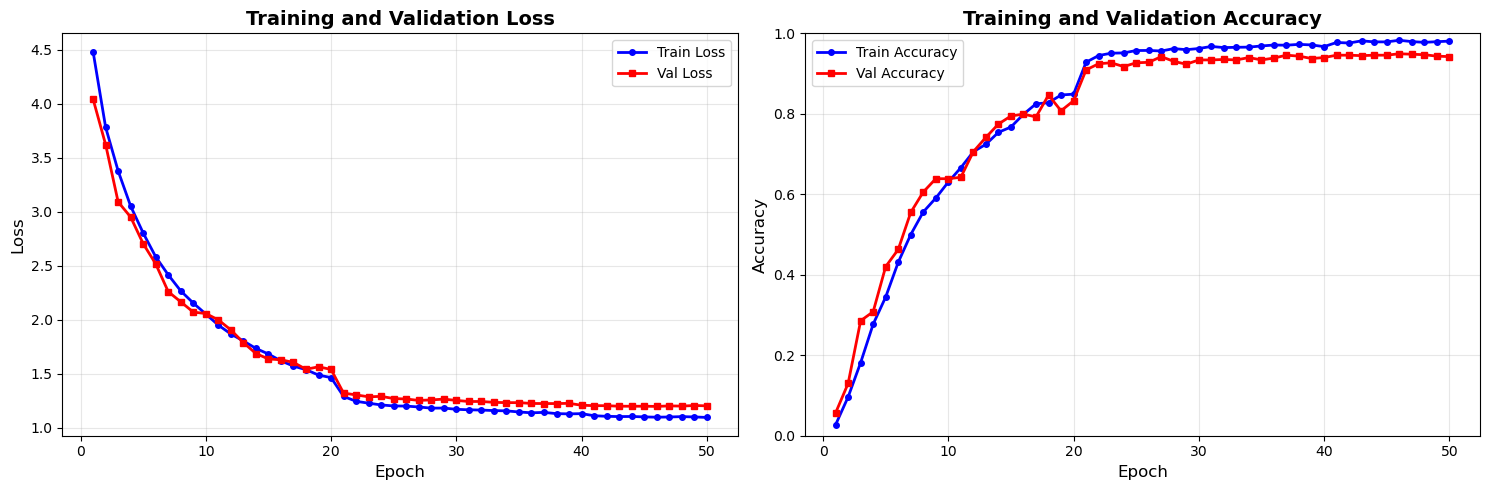

In [42]:
# Plot training curves
with open("results_mamba_og/training_history_mamba.json", "r") as f:
    history = json.load(f)
    plot_path = r"results_mamba_og/training_curves.png"
    plot_training_history(history, save_path=plot_path)
    

## Validation Set Evaluation

In [44]:
# Load best model
print("Loading best model for evaluation...")
best_model_path = r'/mnt/d/FYP/mgcn/checkpoints_mamba_og/best_mamba_gcn.pth'
checkpoint = torch.load(best_model_path, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Evaluate on validation set
print("\nEvaluating on val set...")
val_results = validate(model, val_loader, criterion, Config.DEVICE)

# Compute detailed metrics
val_metrics = compute_detailed_metrics(
    val_results['targets'],
    val_results['predictions'],
    classes
)

# Print summary
print_metrics_summary(val_metrics, split_name="Validation")

# Save metrics to JSON
metrics_path = Path(Config.RESULTS_DIR) / "validation_metrics.json"
with open(metrics_path, 'w') as f:
    json.dump(val_metrics, f, indent=2)
print(f"Validation metrics saved to {metrics_path}")

Loading best model for evaluation...

Evaluating on val set...



Validation Metrics Summary
Accuracy: 0.9492

Macro Averages:
  Precision: 0.9563
  Recall:    0.9492
  F1-Score:  0.9488

Weighted Averages:
  Precision: 0.9563
  Recall:    0.9492
  F1-Score:  0.9488

Validation metrics saved to results_mamba_og/validation_metrics.json


Confusion matrix saved to results_mamba_og/confusion_matrix_val.png


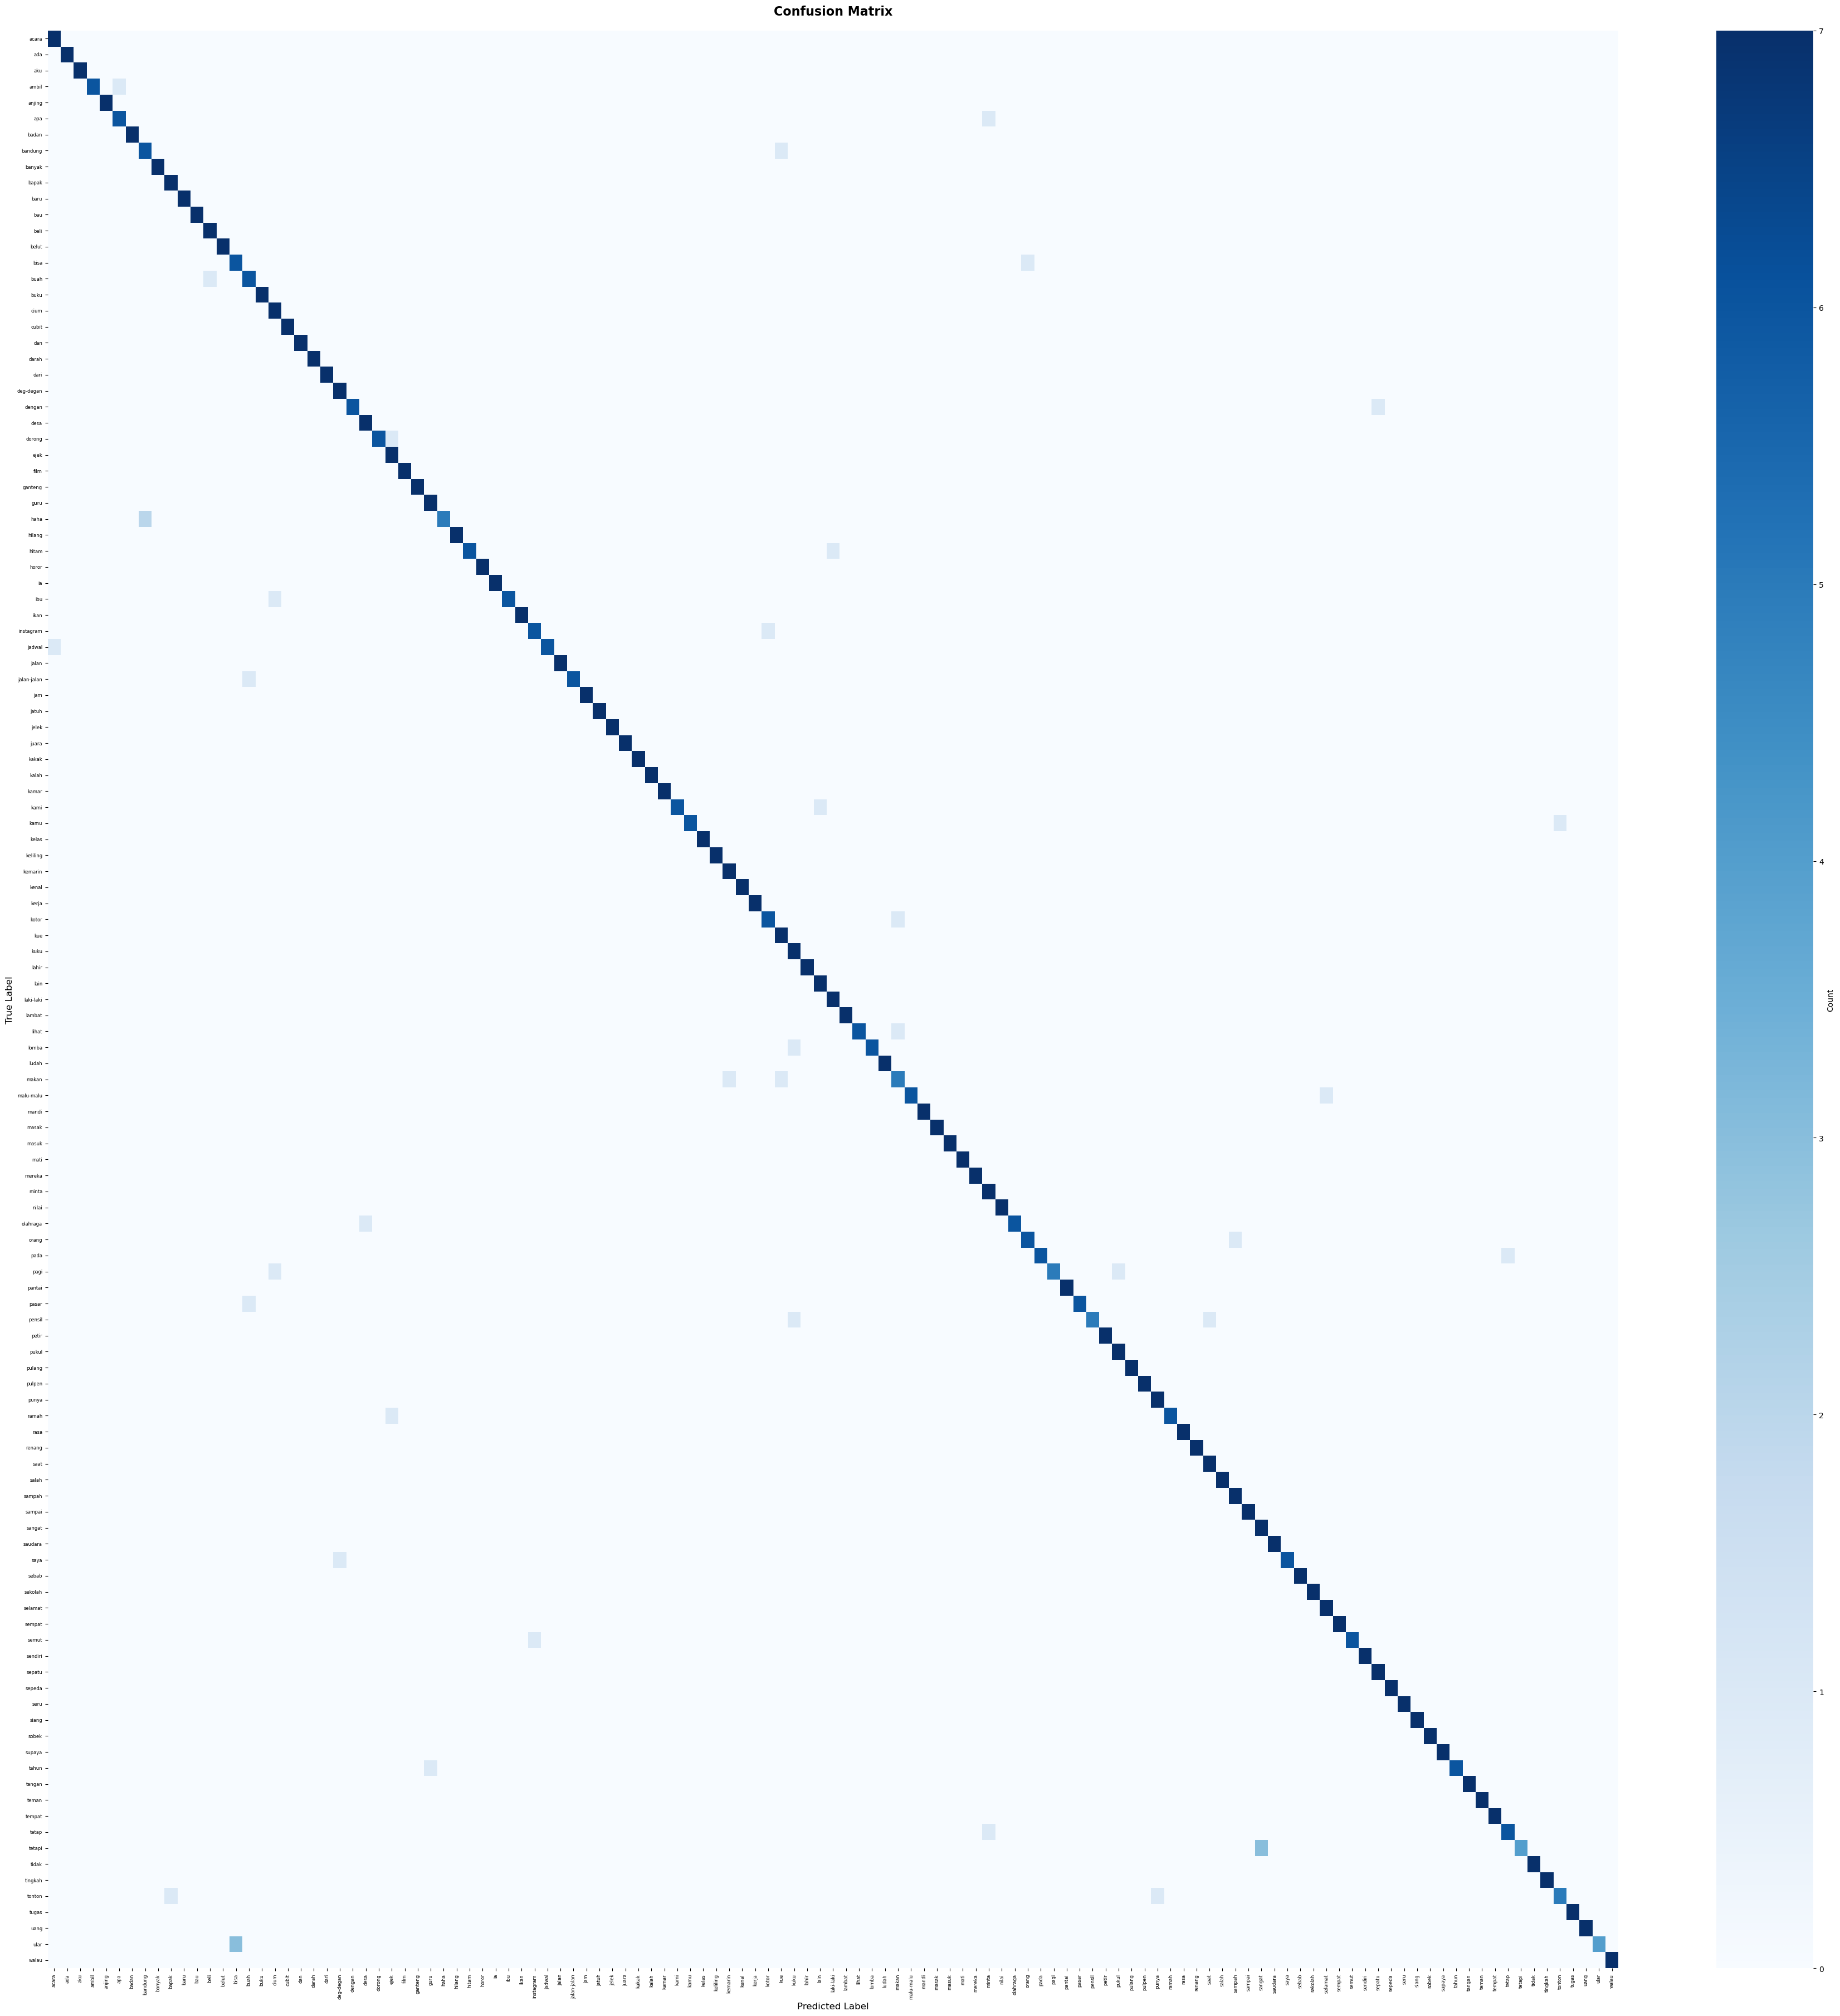

Confusion matrix saved to results_mamba_og/confusion_matrix_val_normalized.png


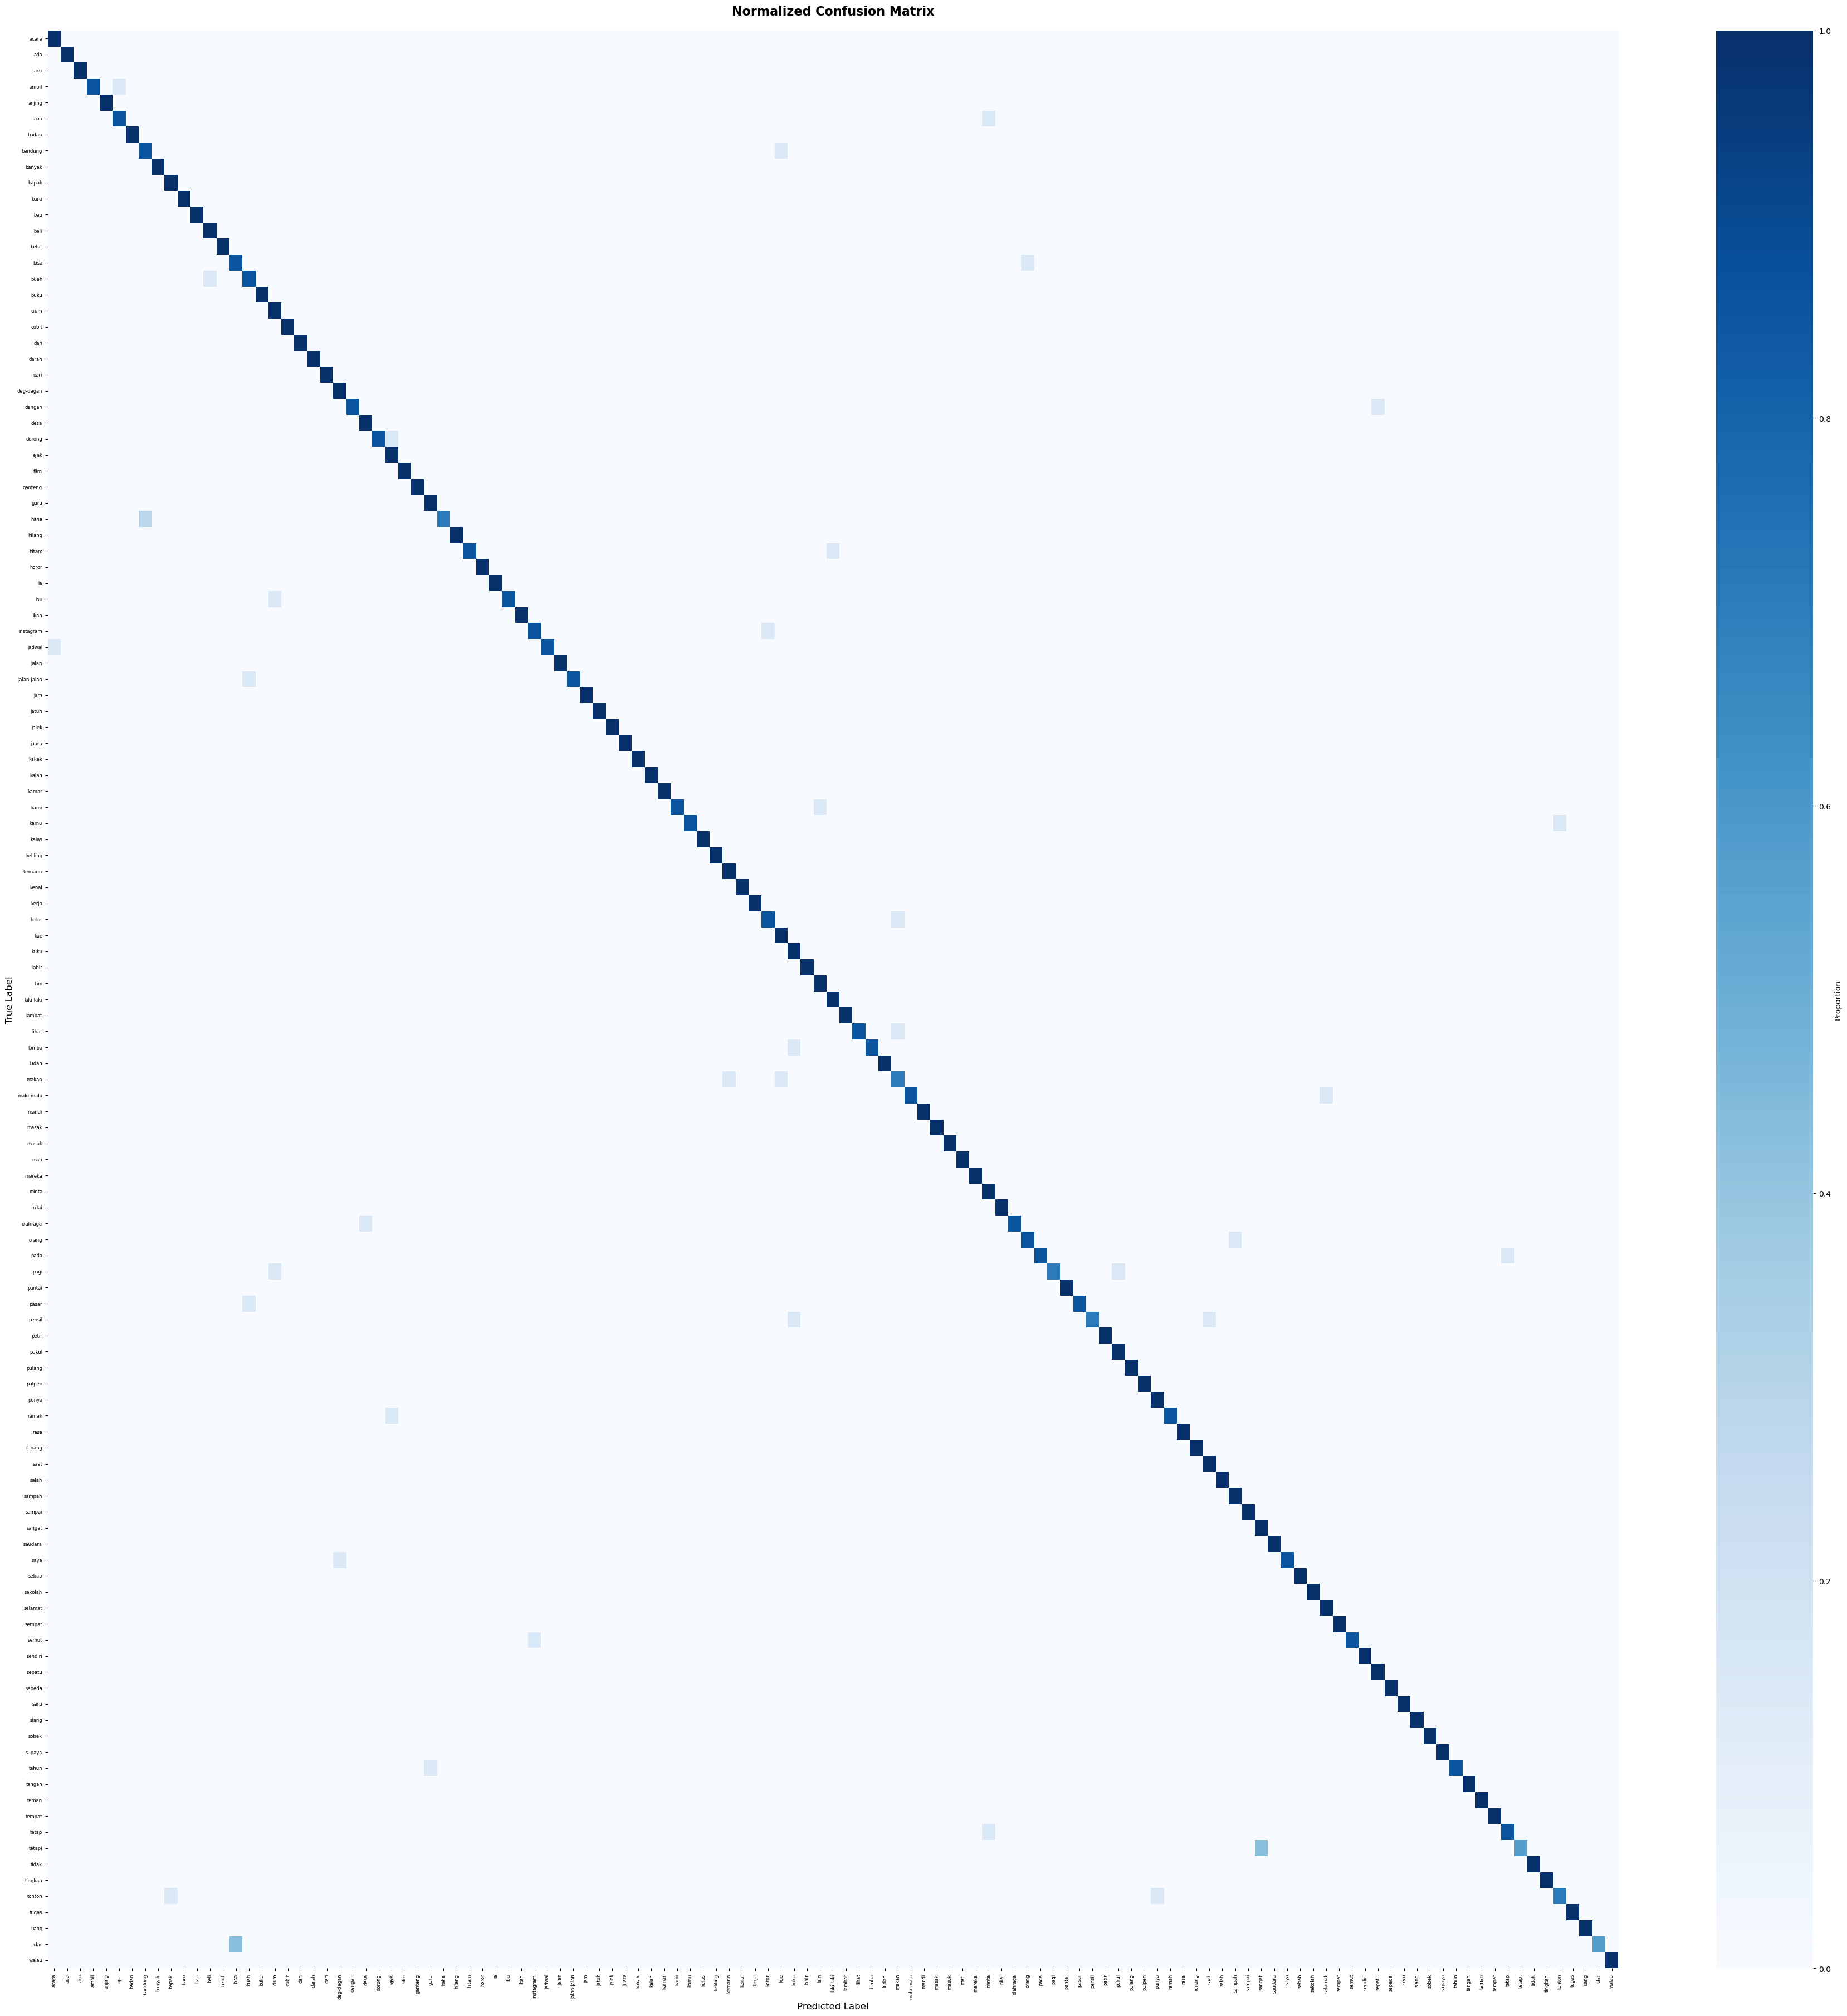

array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.57142857,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        1.        ]], shape=(121, 121))

In [45]:
# Plot confusion matrix (raw counts)
cm_path = Path(Config.RESULTS_DIR) / "confusion_matrix_val.png"
plot_confusion_matrix(
    val_results['targets'],
    val_results['predictions'],
    classes,
    save_path=cm_path,
    normalize=False
)

# Plot normalized confusion matrix
cm_norm_path = Path(Config.RESULTS_DIR) / "confusion_matrix_val_normalized.png"
plot_confusion_matrix(
    val_results['targets'],
    val_results['predictions'],
    classes,
    save_path=cm_norm_path,
    normalize=True
)

In [46]:
# Analyze per-class performance
print("\n" + "="*80)
print("TOP 10 BEST PERFORMING CLASSES (Validation F1-Score)")
print("="*80)

# Sort by F1-score
class_f1 = [(cls, metrics['f1_score']) 
            for cls, metrics in val_metrics['per_class'].items()]
class_f1_sorted = sorted(class_f1, key=lambda x: x[1], reverse=True)

for i, (class_name, f1) in enumerate(class_f1_sorted[:10], 1):
    metrics = val_metrics['per_class'][class_name]
    print(f"{i:2d}. {class_name:30s} | F1: {f1:.4f} | "
          f"Precision: {metrics['precision']:.4f} | "
          f"Recall: {metrics['recall']:.4f} | "
          f"Support: {metrics['support']}")

print("\n" + "="*80)
print("TOP 10 WORST PERFORMING CLASSES (Validation F1-Score)")
print("="*80)

for i, (class_name, f1) in enumerate(class_f1_sorted[-10:][::-1], 1):
    metrics = val_metrics['per_class'][class_name]
    print(f"{i:2d}. {class_name:30s} | F1: {f1:.4f} | "
          f"Precision: {metrics['precision']:.4f} | "
          f"Recall: {metrics['recall']:.4f} | "
          f"Support: {metrics['support']}")

# Save sorted class performance
class_performance = {
    'best_classes': class_f1_sorted[:10],
    'worst_classes': class_f1_sorted[-10:][::-1]
}

perf_path = Path(Config.RESULTS_DIR) / "class_performance.json"
with open(perf_path, 'w') as f:
    json.dump(class_performance, f, indent=2)


TOP 10 BEST PERFORMING CLASSES (Validation F1-Score)
 1. ada                            | F1: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | Support: 7
 2. aku                            | F1: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | Support: 7
 3. anjing                         | F1: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | Support: 7
 4. badan                          | F1: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | Support: 7
 5. banyak                         | F1: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | Support: 7
 6. baru                           | F1: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | Support: 7
 7. bau                            | F1: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | Support: 7
 8. belut                          | F1: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | Support: 7
 9. buku                           | F1: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | Support: 7
10. cubit                          | F1: 1.0000 | Precision: 1.0

## Test Set Evaluation

In [47]:
"""
FINAL TEST SET EVALUATION
Run this after training is complete
"""

# Load best model
print("="*80)
print("FINAL TEST SET EVALUATION")
print("="*80)
print(f"\nLoading best model from: {best_model_path}")

checkpoint = torch.load(best_model_path, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Best model from Epoch {checkpoint['epoch']} (Val Acc: {checkpoint['best_val_acc']:.4f})")

# Evaluate on test set
print("\nRunning inference on test set...")
test_results = validate(model, test_loader, criterion, Config.DEVICE)

# Compute detailed metrics
test_metrics = compute_detailed_metrics(
    test_results['targets'],
    test_results['predictions'],
    classes
)

# Print summary
print_metrics_summary(test_metrics, split_name="Test")

# Save test metrics
test_metrics_path = Path(Config.RESULTS_DIR) / "test_metrics.json"
with open(test_metrics_path, 'w') as f:
    json.dump(test_metrics, f, indent=2)

print(f"Test metrics saved to {test_metrics_path}")

FINAL TEST SET EVALUATION

Loading best model from: /mnt/d/FYP/mgcn/checkpoints_mamba_og/best_mamba_gcn.pth
Best model from Epoch 46 (Val Acc: 0.9492)

Running inference on test set...



Test Metrics Summary
Accuracy: 0.9432

Macro Averages:
  Precision: 0.9476
  Recall:    0.9432
  F1-Score:  0.9418

Weighted Averages:
  Precision: 0.9476
  Recall:    0.9432
  F1-Score:  0.9418

Test metrics saved to results_mamba_og/test_metrics.json


In [48]:
"""
Detailed classification report for test set
"""

from sklearn.metrics import classification_report

print("\n" + "="*80)
print("TEST SET CLASSIFICATION REPORT")
print("="*80 + "\n")

# Generate report
test_report = classification_report(
    test_results['targets'],
    test_results['predictions'],
    target_names=classes,
    digits=4
)
print(test_report)

# Save to file
test_report_path = Path(Config.RESULTS_DIR) / "classification_report_test.txt"
with open(test_report_path, 'w') as f:
    f.write("TEST SET CLASSIFICATION REPORT\n")
    f.write(f"Best Model: Epoch {checkpoint['epoch']}\n")
    f.write(f"Validation Accuracy: {checkpoint['best_val_acc']:.4f}\n")
    f.write("="*80 + "\n\n")
    f.write(test_report)

print(f"\nTest classification report saved to {test_report_path}")


TEST SET CLASSIFICATION REPORT

              precision    recall  f1-score   support

       acara     0.8000    1.0000    0.8889         8
         ada     1.0000    1.0000    1.0000         8
         aku     1.0000    1.0000    1.0000         8
       ambil     1.0000    1.0000    1.0000         8
      anjing     1.0000    1.0000    1.0000         8
         apa     1.0000    0.7500    0.8571         8
       badan     1.0000    1.0000    1.0000         8
     bandung     0.6667    1.0000    0.8000         8
      banyak     1.0000    1.0000    1.0000         8
       bapak     0.8889    1.0000    0.9412         8
        baru     1.0000    0.8750    0.9333         8
         bau     1.0000    1.0000    1.0000         8
        beli     1.0000    1.0000    1.0000         8
       belut     1.0000    1.0000    1.0000         8
        bisa     1.0000    0.7500    0.8571         8
        buah     1.0000    1.0000    1.0000         8
        buku     0.8889    1.0000    0.9412     

## Augmented Test Set Evaluation

In [49]:
"""
FINAL AUGMENTED TEST SET EVALUATION
Run this after training is complete
"""

# Load best model
print("="*80)
print("FINAL TEST SET EVALUATION")
print("="*80)
print(f"\nLoading best model from: {best_model_path}")

checkpoint = torch.load(best_model_path, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Best model from Epoch {checkpoint['epoch']} (Val Acc: {checkpoint['best_val_acc']:.4f})")

# Evaluate on test set
print("\nRunning inference on augmented test set...")
test_results = validate(model, test_augment_loader, criterion, Config.DEVICE)

# Compute detailed metrics
test_metrics = compute_detailed_metrics(
    test_results['targets'],
    test_results['predictions'],
    classes
)

# Print summary
print_metrics_summary(test_metrics, split_name="Test_Augment")

# Save test metrics
test_metrics_path = Path(Config.RESULTS_DIR) / "test_augment_metrics.json"
with open(test_metrics_path, 'w') as f:
    json.dump(test_metrics, f, indent=2)

print(f"Test metrics saved to {test_metrics_path}")

FINAL TEST SET EVALUATION

Loading best model from: /mnt/d/FYP/mgcn/checkpoints_mamba_og/best_mamba_gcn.pth
Best model from Epoch 46 (Val Acc: 0.9492)

Running inference on augmented test set...



Test_Augment Metrics Summary
Accuracy: 0.6016

Macro Averages:
  Precision: 0.6325
  Recall:    0.6015
  F1-Score:  0.5936

Weighted Averages:
  Precision: 0.6326
  Recall:    0.6016
  F1-Score:  0.5937

Test metrics saved to results_mamba_og/test_augment_metrics.json


In [50]:
"""
Detailed classification report for test set
"""

print("\n" + "="*80)
print("AUGMENTED TEST SET CLASSIFICATION REPORT")
print("="*80 + "\n")

# Generate report
test_report = classification_report(
    test_results['targets'],
    test_results['predictions'],
    target_names=classes,
    digits=4
)
print(test_report)

# Save to file
test_report_path = Path(Config.RESULTS_DIR) / "classification_report_test.txt"
with open(test_report_path, 'w') as f:
    f.write("AUGMENTED TEST SET CLASSIFICATION REPORT\n")
    f.write(f"Best Model: Epoch {checkpoint['epoch']}\n")
    f.write(f"Augmented Test Accuracy: {checkpoint['best_val_acc']:.4f}\n")
    f.write("="*80 + "\n\n")
    f.write(test_report)

print(f"\nTest classification report saved to {test_report_path}")


AUGMENTED TEST SET CLASSIFICATION REPORT

              precision    recall  f1-score   support

       acara     0.3636    0.5333    0.4324        15
         ada     0.5882    0.6250    0.6061        16
         aku     0.5185    0.8750    0.6512        16
       ambil     0.9000    0.5625    0.6923        16
      anjing     1.0000    0.8125    0.8966        16
         apa     0.5000    0.2500    0.3333        16
       badan     0.6400    1.0000    0.7805        16
     bandung     0.6667    0.7500    0.7059        16
      banyak     0.7143    0.3125    0.4348        16
       bapak     0.6875    0.6875    0.6875        16
        baru     0.7500    0.7500    0.7500        16
         bau     0.5789    0.6875    0.6286        16
        beli     0.4286    0.1875    0.2609        16
       belut     0.8571    0.7500    0.8000        16
        bisa     0.4737    0.5625    0.5143        16
        buah     0.6923    0.5625    0.6207        16
        buku     0.6364    0.4375    0